In [12]:
# import pandas as pd
import fireducks.pandas as pd
import numpy as np
from IPython.display import SVG, display
import pandas as pd
import networkx as nx
import matplotlib.pyplot as pp


In [13]:
def make_timeseries(start="2000-01-01", end="2000-03-31", freq="1D", seed=None):
    index = pd.date_range(start=start, end=end, freq=freq, name="timestamp")
    n = len(index)
    state = np.random.RandomState(seed)
    columns = {
        "name": state.choice(["Alicia", "Liliam", "Cleverson","Julia","Pedro","Jake"], size=n),
        "id": np.arange(1,n+1) ,
        "x": state.rand(n) * 2 - 1,
        "y": state.rand(n) * 2 - 1,
    }
    
    df = pd.DataFrame(columns, index=index, columns=sorted(columns))
    if df.index[-1] == end:
        df = df.iloc[:-1]
    return df

In [14]:
timeseries = [
    make_timeseries(freq="15min", seed=i).rename(columns=lambda x: f"{x}_{i}")
    for i in range(1)
]

ts_wide = pd.concat(timeseries, axis=1)
ts_wide = ts_wide.sort_values(by=['name_0','id_0','timestamp'])
#ts_wide = ts_wide.reset_index()
ts_wide.head()

,id_0,name_0,x_0,y_0
timestamp,,,,
2000-01-01 00:30:00,3,Alicia,0.731301,0.886211
2000-01-01 02:45:00,12,Alicia,0.933612,0.611009
2000-01-01 03:00:00,13,Alicia,-0.839464,0.745467
2000-01-01 04:00:00,17,Alicia,0.474595,0.935662
2000-01-01 05:15:00,22,Alicia,-0.651259,-0.440390


In [15]:
import subprocess

# Definindo o caminho para o script Julia
julia_script = "demo_integracao.jl"
ts_wide.to_csv('data.csv', index=True)
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

In [16]:
from sqlalchemy import create_engine

# Criar uma conexão com o banco de dados (exemplo: SQLite)
# Para outros bancos de dados, ajuste a string de conexão
engine = create_engine('sqlite:///data_SQL.db')

# 3. Escrever o DataFrame no banco de dados
ts_wide.to_sql('Tabela_TESTE', con=engine, if_exists='replace', index=True)

print("Dados gravados no banco de dados com sucesso!")
# Definindo o caminho para o script Julia
julia_script = "demo_integracao_SQL.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

Dados gravados no banco de dados com sucesso!


In [17]:
# # Função para ler o arquivo e salvar os parâmetros
# def read_parameters(file_path):
#     params = {}
    
#     # Ler o arquivo linha por linha
#     with open(file_path, 'r') as file:
#         for line in file:
#             # Ignorar linhas vazias
#             line = line.strip()
#             if not line:
#                 continue
            
#             # Separar o parâmetro e o valor
#             key_value = line.split(';')
#             if len(key_value) == 2:
#                 key, value = key_value[0].strip(), key_value[1].strip()
#                 params[key] = value
                
#     return params

# # Usar a função para ler os parâmetros do arquivo
# parametros = read_parameters('../UNTRACKED/ODBC_connect/log_info.txt')

# # Criar a string de conexão
# connection_string = f"mariadb+mariadbconnector://{parametros['user']}:{parametros['password']}@{parametros['host']}/{parametros['database']}"

# # Criar o engine
# engine = create_engine(connection_string)

# # 3. Escrever o DataFrame no banco de dados
# ts_wide.to_sql('Tabela_TESTE_nova', con=engine, if_exists='replace', index=True)
# print("Dados gravados no banco de dados com sucesso!")
# # Definindo o caminho para o script Julia
# julia_script = "demo_integracao_ODBC.jl"
# # Executando o script Julia usando subprocess
# try:
#     subprocess.run(["julia", julia_script], check=True)
# except subprocess.CalledProcessError as e:
#     print(f"Ocorreu um erro ao executar o script Julia: {e}")

# Algebra Linear

In [18]:
# Definindo o caminho para o script Julia
julia_script = "algebra_linear.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

[ Info: Using cofactor expansion to calculate determinant; may be very slow.


# Grafos

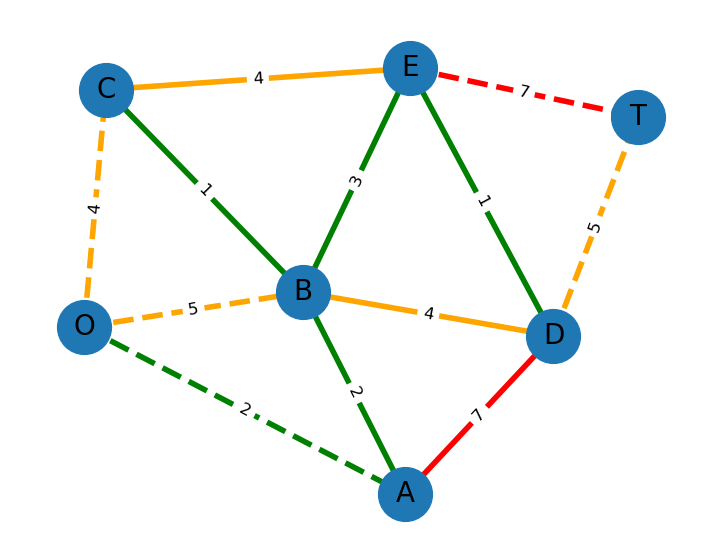

In [19]:
def criar_grafo_e_plotar(df):
    G = nx.Graph()

    # Adiciona as arestas com pesos
    for _, row in df.iterrows():
        origem = row['PONTO_ORIGEM']
        destino = row['PONTO_DESTINO']
        peso = row['DISTANCIA']
        G.add_edge(origem, destino, weight=peso)

    pos = nx.spring_layout(G, seed=0)

    # Separar arestas com base nas regras
    for u, v, d in G.edges(data=True):
        peso = d['weight']

        # Define a cor
        if peso <= 3:
            cor = 'green'
        elif 4 <= peso <= 6:
            cor = 'orange'
        else:
            cor = 'red'

        # Define o estilo
        if 'O' in (u, v) or 'T' in (u, v):
            estilo = 'dashed'
        else:
            estilo = 'solid'

        # Salva os atributos na aresta
        d['color'] = cor
        d['style'] = estilo

    # Plotagem
    pp.figure(figsize=(9, 7))
    nx.draw_networkx_nodes(G, pos, node_size=1500)
    nx.draw_networkx_labels(G, pos, font_size=20, font_family='sans-serif')

    # Desenha as arestas uma a uma para aplicar estilo individual
    for u, v, d in G.edges(data=True):
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            width=4,
            edge_color=d['color'],
            style=d['style']
        )

    # Rótulo de peso nas arestas
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12)

    pp.margins(0.1)
    pp.axis('off')
    pp.show()

    return G


df_grafo = pd.read_csv('grafo_SeervadaPark.csv', sep=';')
criar_grafo_e_plotar(df=df_grafo)

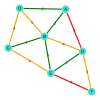

In [ ]:
# Definindo o caminho para o script Julia
julia_script = "demo_graph.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

display(SVG("graph_SeervadaPark.svg"))
